> **Historical investigation ? not the current workflow.**
> Open `90_consolidated_ggr.ipynb` for daily analysis and `20_run_all_collectors.ipynb` for updates.
> The code and saved outputs below reflect an earlier snapshot. Pinned hashes, counts,
> parser-defect assertions, and proposed mappings may no longer match the current code or data.
> Kept as research history; not maintained as a Run All notebook.

# Cross-state metric contract walkthrough

## 1. Objective and boundaries

**What this notebook does.** It audits `data/gaming.sqlite` and proposes how state gaming metrics can be *standardized* without pretending that GGR, AGR, taxable revenue, and net proceeds are the same number.

**Standardization here means:** identity (state, vertical, channel), periods, frequency, units, provenance, and eligibility rules — not forcing every jurisdiction into one revenue column.

**Why the native columns stay separate.** The database intentionally retains `gross_revenue`, `adjusted_revenue`, `taxable_revenue`, and `net_proceeds` because regulators define different economic or legal stages. Collapsing them silently would misstate cross-state comparisons.

**What this notebook does not do.** It does not change the schema, production collectors, or consolidated exports. It produces separate views for strict reported-GGR semantics, gross-win-equivalent bridges, state-native cohorts, and a common-month observation cohort.

**New Jersey note.** The controlled NJ sportsbook GGR replay has been completed and promoted into this database. NJ sportsbook GGR is now usable for monthly GGR trends, operator-level GGR analysis, and operator share of reported GGR. NJ remains unusable for hold, handle growth, or any handle-dependent comparison because official NJ reports do not provide sportsbook handle. Missing handle must remain NULL and must never be estimated or zero-filled.


## 2. Read-only setup and reproducibility

**What.** Connect to SQLite with `mode=ro`, record environment metadata, and verify we are not writing to the production database.

**Why.** Methodology work must not mutate retained observations. Hash checks before and after execution prove immutability.

**Tradeoff.** We assert read-only via URI inspection rather than attempting a deliberate write against production.

**Inspect.** Database path, hash, Python/package versions, and table list.


In [1]:
from __future__ import annotations

import sqlite3
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import project_root
from variant_gaming.consolidate import dedupe_latest_observation, revenue_basis, build_state_period_revenue
from variant_gaming.storage import default_db_path

ROOT = project_root()
DATABASE_PATH = default_db_path(ROOT)
EXPECTED_DB_HASH = "62AFD2B97459F151E62FBBF24C7E0D0FE5A52E9DEE829931D2554B9B1529D388"

import hashlib

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

DB_HASH_BEFORE = sha256_file(DATABASE_PATH)
print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Database:", DATABASE_PATH)
print("Database hash (before):", DB_HASH_BEFORE)
assert DB_HASH_BEFORE.lower() == EXPECTED_DB_HASH.lower()

DB_URI = f"file:{DATABASE_PATH.as_posix()}?mode=ro"
connection = sqlite3.connect(DB_URI, uri=True)
print("Connection URI:", DB_URI)
assert "mode=ro" in DB_URI

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    connection,
)
display(tables)
for table in tables["name"]:
    schema = pd.read_sql_query(f"PRAGMA table_info({table})", connection)
    print(f"\n{table} schema")
    display(schema)


Repository root: C:\Users\Sean\VscProjects\researchOS
Python: 3.11.9
pandas: 3.0.5
Database: C:\Users\Sean\VscProjects\researchOS\data\gaming.sqlite
Database hash (before): 62afd2b97459f151e62fbbf24c7e0d0fe5a52e9dee829931d2554b9b1529d388
Connection URI: file:C:/Users/Sean/VscProjects/researchOS/data/gaming.sqlite?mode=ro

gaming_results schema

gaming_results_legacy schema

source_coverage schema


,name
0,gaming_results
1,gaming_results_legacy
2,source_coverage


,cid,name,type,notnull,dflt_value,pk
0,0,jurisdiction,TEXT,1,None,0
1,1,state_code,TEXT,1,None,1
2,2,vertical,TEXT,1,None,2
3,3,channel,TEXT,1,None,3
4,4,operator,TEXT,1,None,4
5,5,row_type,TEXT,1,None,5
6,6,period_start,TEXT,1,None,6
7,7,period_end,TEXT,1,None,7
8,8,frequency,TEXT,1,None,0
9,9,handle,REAL,0,None,0


,cid,name,type,notnull,dflt_value,pk
0,0,jurisdiction,TEXT,0,None,0
1,1,state_code,TEXT,0,None,0
2,2,vertical,TEXT,0,None,0
3,3,channel,TEXT,0,None,0
4,4,operator,TEXT,0,None,0
5,5,period_start,TEXT,0,None,0
6,6,period_end,TEXT,0,None,0
7,7,handle,REAL,0,None,0
8,8,gross_revenue,TEXT,0,None,0
9,9,adjusted_revenue,TEXT,0,None,0


,cid,name,type,notnull,dflt_value,pk
0,0,state_code,TEXT,1,None,1
1,1,vertical,TEXT,1,None,2
2,2,status,TEXT,1,None,0
3,3,reason,TEXT,0,None,0
4,4,official_url,TEXT,0,None,0
5,5,available_frequency,TEXT,0,None,0
6,6,earliest_period,TEXT,0,None,0
7,7,latest_period,TEXT,0,None,0
8,8,downloaded_file_count,INTEGER,0,None,0
9,9,normalized_row_count,INTEGER,0,None,0


## 3. Raw data inspection

**What.** Inventory row counts, dtypes, missingness, duplicate business keys, and coverage dimensions.

**Why.** Before classifying metrics we must understand what the database actually contains — not what we wish it contained.

**Assumption.** `gaming_results` primary key includes `source_sha256`, so revisions appear as separate rows rather than overwrites.

**Inspect.** Shapes, representative rows, period spans, and operator-name diversity.


In [2]:
results = pd.read_sql_query("SELECT * FROM gaming_results", connection)
coverage = pd.read_sql_query("SELECT * FROM source_coverage", connection)

print("gaming_results shape:", results.shape)
print("source_coverage shape:", coverage.shape)
display(results.dtypes.to_frame("dtype"))
display(results.head(3))
display(results.isna().mean().sort_values(ascending=False).head(12).to_frame("missing_rate"))

business_key = [
    "state_code", "vertical", "channel", "operator", "row_type",
    "period_start", "period_end",
]
dup_counts = results.groupby(business_key).size().reset_index(name="source_versions")
revised_keys = dup_counts.loc[dup_counts["source_versions"] > 1]
print("Business keys with multiple source hashes:", len(revised_keys))
display(revised_keys.sort_values("source_versions", ascending=False).head(8))

for label, col in [
    ("states", "state_code"), ("verticals", "vertical"), ("channels", "channel"),
    ("frequencies", "frequency"), ("row_types", "row_type"), ("statuses", "report_status"),
]:
    print(label)
    display(results[col].value_counts().to_frame("rows"))

period_span = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .agg(earliest=("period_start", "min"), latest=("period_end", "max"), rows=("period_start", "size"))
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(period_span)

metric_cols = ["handle", "gross_revenue", "adjusted_revenue", "taxable_revenue", "net_proceeds", "tax"]
display(results[metric_cols].notna().sum().to_frame("non_null_rows"))

operator_counts = (
    results.loc[results["row_type"] == "operator"]
    .groupby(["state_code", "vertical"])["operator"]
    .nunique()
    .reset_index(name="operator_count")
)
display(operator_counts.sort_values("operator_count", ascending=False).head(10))

source_counts = (
    results.groupby(["state_code", "vertical"])
    .agg(distinct_hashes=("source_sha256", "nunique"), distinct_files=("source_file", "nunique"))
    .reset_index()
    .sort_values("distinct_hashes", ascending=False)
)
display(source_counts.head(10))


gaming_results shape: (18582, 21)
source_coverage shape: (42, 11)
Business keys with multiple source hashes: 2
states
verticals
channels
frequencies
row_types
statuses


,dtype
jurisdiction,str
state_code,str
vertical,str
channel,str
operator,str
row_type,str
period_start,str
period_end,str
frequency,str
handle,float64


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status
0,Illinois,IL,online_sports_betting,online,STATEWIDE,official_statewide_total,2020-03-01,2020-03-31,monthly,0.0,NaN,0.0,NaN,NaN,0.0,State AGR,https://igb.illinois.gov/sports-wagering/sports-reports.html,data/raw/IL/2026-09-03/79a565a2c2c355f3f79bb55cfdf53bf02fe46a1125faa52582c38129b11797cb_il_sport_detail_2020-03.csv|data/raw/IL/2026-09-03/71c246bcaa99e8bba2cc6dc77808ea64b850da147333849620ce2e758dbfd70b_il_tax_summary_2020-03.csv,11b26addf121621ba7ab7b55c763a0b680ac114e84fe75bb3de66dada2b84802,2026-09-03T01:41:29.956150+00:00,derived_from_operator_sum
1,Illinois,IL,online_sports_betting,online,"Alton Casino, LLC",operator,2020-03-01,2020-03-31,monthly,0.0,NaN,0.0,NaN,NaN,0.0,State AGR,https://igb.illinois.gov/sports-wagering/sports-reports.html,data/raw/IL/2026-09-03/79a565a2c2c355f3f79bb55cfdf53bf02fe46a1125faa52582c38129b11797cb_il_sport_detail_2020-03.csv|data/raw/IL/2026-09-03/71c246bcaa99e8bba2cc6dc77808ea64b850da147333849620ce2e758dbfd70b_il_tax_summary_2020-03.csv,11b26addf121621ba7ab7b55c763a0b680ac114e84fe75bb3de66dada2b84802,2026-09-03T01:41:29.956150+00:00,ok
2,Illinois,IL,online_sports_betting,online,"Midwest Gaming & Entertainment, LLC",operator,2020-03-01,2020-03-31,monthly,0.0,NaN,0.0,NaN,NaN,0.0,State AGR,https://igb.illinois.gov/sports-wagering/sports-reports.html,data/raw/IL/2026-09-03/79a565a2c2c355f3f79bb55cfdf53bf02fe46a1125faa52582c38129b11797cb_il_sport_detail_2020-03.csv|data/raw/IL/2026-09-03/71c246bcaa99e8bba2cc6dc77808ea64b850da147333849620ce2e758dbfd70b_il_tax_summary_2020-03.csv,11b26addf121621ba7ab7b55c763a0b680ac114e84fe75bb3de66dada2b84802,2026-09-03T01:41:29.956150+00:00,ok


,missing_rate
net_proceeds,0.875794
adjusted_revenue,0.838446
taxable_revenue,0.680551
tax,0.444462
gross_revenue,0.360564
handle,0.186309
operator,0.000000
vertical,0.000000
state_code,0.000000
jurisdiction,0.000000


,state_code,vertical,channel,operator,row_type,period_start,period_end,source_versions
7545,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-03-01,2024-03-31,2
7549,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-07-01,2024-07-31,2


...

,rows
report_status,
ok,18331
derived_from_operator_sum,156
unaudited,62
limited_metrics_handle_and_tax_only,31
limited_metrics_handle_and_tax_only; unaudited,2


,state_code,vertical,earliest,latest,rows
0,CT,online_casino,2021-10-01,2026-07-31,223
1,CT,online_sports_betting,2021-10-01,2026-07-31,174
2,DC,online_sports_betting,2024-07-01,2026-07-31,62
3,DE,online_casino,2013-11-01,2026-07-31,612
4,IA,online_sports_betting,2019-08-01,2026-07-31,1669
5,IL,online_sports_betting,2020-03-01,2026-06-30,891
6,IN,online_sports_betting,2019-10-01,2026-07-31,1025
7,LA,online_sports_betting,2021-07-01,2026-07-31,55
8,MA,online_sports_betting,2023-03-01,2026-07-31,291
9,MD,online_sports_betting,2024-08-01,2026-07-31,351


,non_null_rows
handle,15120
gross_revenue,11882
adjusted_revenue,3002
taxable_revenue,5936
net_proceeds,2308
tax,10323


,state_code,vertical,operator_count
13,NJ,online_sports_betting,85
4,IA,online_sports_betting,52
3,DE,online_casino,48
12,NJ,online_casino,47
10,MI,online_sports_betting,26
9,MI,online_casino,26
6,IN,online_sports_betting,26
15,OH,online_sports_betting,23
17,PA,online_sports_betting,19
5,IL,online_sports_betting,16


,state_code,vertical,distinct_hashes,distinct_files
15,NJ,online_casino,127,127
16,NJ,online_sports_betting,98,98
6,IN,online_sports_betting,82,82
5,IL,online_sports_betting,76,76
8,MA,online_sports_betting,41,41
21,TN,online_sports_betting,33,33
2,DC,online_sports_betting,25,25
9,MD,online_sports_betting,23,23
3,DE,online_casino,14,14
17,NY,online_sports_betting,10,10


## 4. Revisions and current-observation logic

**What.** Distinguish immutable source observations from the *latest* analytical observation selected for each business key.

**Why.** Official reports get restated. Charts should not double-count the same period, but audits must retain every hash.

**Method.** Reuse `dedupe_latest_observation` from `variant_gaming.consolidate`. Keep all native revenue columns in the audit — do not rely only on a single consolidated `revenue` field.

**Alternative considered.** Re-ingest only latest files. Rejected here because it would hide revision history needed for point-in-time review.

**Inspect.** Examples of revised keys, retrieval timestamps, and rows with multiple revenue measures.


In [3]:
latest = dedupe_latest_observation(results)
print(f"Raw rows: {len(results):,} | Latest observations: {len(latest):,}")

revision_audit = (
    results.assign(retrieved_sort=pd.to_datetime(results["retrieved_at_utc"], utc=True, errors="coerce"))
    .sort_values("retrieved_sort")
    .groupby(business_key, dropna=False)
    .agg(
        source_versions=("source_sha256", "nunique"),
        first_retrieved=("retrieved_sort", "min"),
        last_retrieved=("retrieved_sort", "max"),
        latest_hash=("source_sha256", "last"),
    )
    .reset_index()
)
display(revision_audit.loc[revision_audit["source_versions"] > 1].head(8))

invalid_ts = results.loc[results["retrieved_at_utc"].isna() | (results["retrieved_at_utc"] == "")]
print("Rows with missing retrieved_at_utc:", len(invalid_ts))

revenue_cols = ["gross_revenue", "adjusted_revenue", "taxable_revenue", "net_proceeds"]
latest = latest.copy()
latest["revenue_measure_count"] = latest[revenue_cols].notna().sum(axis=1)
multi_revenue = latest.loc[latest["revenue_measure_count"] > 1].copy()
print("Latest rows with multiple revenue measures:", len(multi_revenue))
display(
    multi_revenue[
        ["state_code", "vertical", "channel", "period_start", "reported_revenue_name"]
        + revenue_cols
    ].head(10)
)


Raw rows: 18,582 | Latest observations: 18,580
Rows with missing retrieved_at_utc: 0
Latest rows with multiple revenue measures: 4625


,state_code,vertical,channel,operator,row_type,period_start,period_end,source_versions,first_retrieved,last_retrieved,latest_hash
7545,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-03-01,2024-03-31,2,2026-09-03 01:58:05.511114+00:00,2026-09-03 02:06:56.113399+00:00,0d080692559f2f440c4a79a9390e436b887ca02545b3ce5bcb52d054065bc649
7549,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-07-01,2024-07-31,2,2026-09-03 01:58:05.511114+00:00,2026-09-03 02:06:56.113399+00:00,a698d2ae69921a3328b8deeaff4d39e3cb2c438609f7b9bfabafcce04dbe681a


,state_code,vertical,channel,period_start,reported_revenue_name,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds
1577,IN,online_sports_betting,online,2020-05-01,Taxable AGR,3237372.00,NaN,3179968.00,NaN
1542,IN,online_sports_betting,online,2020-05-01,Taxable AGR,1801639.00,NaN,1826693.00,NaN
1543,IN,online_sports_betting,online,2020-05-01,Taxable AGR,1056061.00,NaN,1063474.00,NaN
1544,IN,online_sports_betting,online,2020-05-01,Taxable AGR,2755.00,NaN,0.00,NaN
1545,IN,online_sports_betting,online,2020-05-01,Taxable AGR,123467.00,NaN,114210.00,NaN
1546,IN,online_sports_betting,online,2020-05-01,Taxable AGR,168721.00,NaN,175591.00,NaN
1547,IN,online_sports_betting,online,2020-05-01,Taxable AGR,74687.00,NaN,0.00,NaN
1549,IN,online_sports_betting,online,2020-05-01,Taxable AGR,10042.00,NaN,0.00,NaN
1531,IN,online_sports_betting,online,2020-11-01,Taxable AGR,794517.17,NaN,2534334.77,NaN
1449,IN,online_sports_betting,online,2024-07-01,Taxable AGR,18152.45,NaN,11407.91,NaN


## 5. State-by-metric inventory

**What.** Build one row per state and vertical summarizing metric availability, frequency, channel scope, and coverage status.

**Why.** Eligibility rules apply to what is actually populated — not to what a collector intends to populate someday.

**Rule.** Never coalesce different revenue columns into one unlabeled total in this inventory.


In [4]:
metric_cols = ["handle", "gross_revenue", "adjusted_revenue", "taxable_revenue", "net_proceeds", "tax"]

def metric_inventory(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (state, vertical), group in frame.groupby(["state_code", "vertical"], dropna=False):
        row = {
            "state_code": state,
            "vertical": vertical,
            "rows": len(group),
            "native_frequency": ", ".join(sorted(group["frequency"].dropna().unique())),
            "channel_scope": ", ".join(sorted(group["channel"].dropna().unique())),
            "row_types": ", ".join(sorted(group["row_type"].dropna().unique())),
            "earliest_period": group["period_start"].min(),
            "latest_period": group["period_end"].max(),
            "reported_revenue_names": ", ".join(sorted(group["reported_revenue_name"].dropna().unique())[:4]),
        }
        for col in metric_cols:
            row[f"{col}_rows"] = int(group[col].notna().sum())
            row[f"{col}_share"] = round(group[col].notna().mean(), 3)
        row["multi_revenue_rows"] = int((group[revenue_cols].notna().sum(axis=1) > 1).sum())
        rows.append(row)
    out = pd.DataFrame(rows).sort_values(["state_code", "vertical"]).reset_index(drop=True)
    cov = coverage[["state_code", "vertical", "status", "reason"]].rename(columns={"status": "coverage_status"})
    return out.merge(cov, on=["state_code", "vertical"], how="left")

inventory = metric_inventory(latest)
display(inventory)
display(inventory.loc[inventory["multi_revenue_rows"] > 0, ["state_code", "vertical", "multi_revenue_rows"]])


,state_code,vertical,rows,native_frequency,channel_scope,row_types,earliest_period,latest_period,reported_revenue_names,handle_rows,handle_share,gross_revenue_rows,gross_revenue_share,adjusted_revenue_rows,adjusted_revenue_share,taxable_revenue_rows,taxable_revenue_share,net_proceeds_rows,net_proceeds_share,tax_rows,tax_share,multi_revenue_rows,coverage_status,reason
0,CT,online_casino,223,monthly,online,operator,2021-10-01,2026-07-31,Total Gross Gaming Revenue,223,1.000,223,1.000,0,0.00,0,0.000,0,0.000,223,1.000,0,ok,data.ct.gov source CSV imqd-at3c (dashboard se2q-sh9j is chart-only; not scraped as pixels)
1,CT,online_sports_betting,174,monthly,online,operator,2021-10-01,2026-07-31,Total Gross Gaming Revenue,174,1.000,174,1.000,0,0.00,0,0.000,0,0.000,174,1.000,0,ok,data.ct.gov source CSV xf6g-659c (dashboard 2b8v-xwd3 is chart-only; not scraped as pixels)
2,DC,online_sports_betting,62,monthly,online,operator,2024-07-01,2026-07-31,Gross Gaming Revenue (GGR),62,1.000,61,0.984,0,0.00,0,0.000,0,0.000,60,0.968,0,ok,Class C / mobile-app locations only; Class A/B physical venues excluded (no online split); 48 months had no online location rows
3,DE,online_casino,612,monthly,online,"official_statewide_total, operator",2013-11-01,2026-07-31,"Net, Total Net Gaming Revenue",612,1.000,0,0.000,0,0.00,0,0.000,612,1.000,0,0.000,0,ok,Collected DE iGaming monthly net proceeds / Total Net Gaming Revenue
4,IA,online_sports_betting,1669,monthly,online,"official_statewide_total, operator",2019-08-01,2026-07-31,INTERNET NET RECEIPTS,1660,0.995,0,0.000,0,0.00,0,0.000,1641,0.983,0,0.000,0,ok,Collected IRGC INTERNET NET RECEIPTS by casino licensee (retail excluded)
5,IL,online_sports_betting,891,monthly,online,"official_statewide_total, operator",2020-03-01,2026-06-30,State AGR,891,1.000,0,0.000,882,0.99,0,0.000,0,0.000,882,0.990,0,partial,January 2020: No Sport Detail CSV for January 2020; February 2020: No Sport Detail CSV for February 2020; July 2026: No Sport Detail CSV for July 2026; August 2026: No Sport Detail CSV for August 2026
6,IN,online_sports_betting,1025,monthly,online,"official_statewide_total, operator",2019-10-01,2026-07-31,"Gross Receipts, Taxable AGR",1025,1.000,1025,1.000,0,0.00,47,0.046,0,0.000,47,0.046,47,partial,2019-07-Revenue.xlsx: no online brand rows; 2019-08-Revenue.xlsx: no online brand rows; 2019-09-Revenue.xlsx: no online brand rows
7,LA,online_sports_betting,55,monthly,online,official_statewide_total,2021-07-01,2026-07-31,Net Proceeds,55,1.000,0,0.000,0,0.00,0,0.000,55,1.000,55,1.000,0,ok,LSP Sportsbook Mobile Excel: Wagers Written + Net Proceeds + Taxes Paid
8,MA,online_sports_betting,291,monthly,online,operator,2023-03-01,2026-07-31,Taxable Gaming Revenue,291,1.000,291,1.000,0,0.00,291,1.000,0,0.000,291,1.000,291,ok,MGC consolidated monthly PDFs: Category 3 operator rows with taxable revenue
9,MD,online_sports_betting,351,monthly,online,"official_statewide_total, operator",2024-08-01,2026-07-31,Taxable Win,351,1.000,0,0.000,0,0.00,351,1.000,0,0.000,351,1.000,0,partial,February 2026: No Sports Wagering Data Excel download found on release page


,state_code,vertical,multi_revenue_rows
6,IN,online_sports_betting,47
8,MA,online_sports_betting,291
10,MI,online_casino,1060
11,MI,online_sports_betting,1060
16,NJ,online_sports_betting,1422
18,OH,online_sports_betting,745


## 6. Provisional metric contract

**What.** Draft an effective-dated metric contract entirely inside the notebook, covering every `state_code` + `vertical` in `source_coverage` and `gaming_results`.

**Why.** Cross-state comparison requires explicit definitions, not column-name inference alone.

**Rules.**
- Use `valid_from` / `valid_to` only when supported by official evidence; otherwise leave `None` and document uncertainty.
- Populate `official_url` from `source_coverage` whenever available.
- Keep current stored metrics separate from potential future enriched metrics.
- If the official definition is not established here, set `canonical_basis = unknown` and `comparison_class = needs_source_review`.

**Inspect.** Each row's `evidence_note`, `uncertainty`, eligibility flags, and the separate candidate-bridge table for future enriched metrics.



In [5]:
CANONICAL_BASIS = {
    "gross_win_before_promotions", "gross_win_before_federal_excise", "adjusted_gross_revenue",
    "taxable_revenue", "net_proceeds", "handle_only", "unknown",
}
COMPARISON_CLASS = {
    "strict_reported_ggr", "reported_ggr_no_handle", "gross_win_equivalent_candidate",
    "state_native_only", "handle_only", "unusable_or_quarantined", "needs_source_review",
}

coverage_urls = (
    coverage.drop_duplicates(["state_code", "vertical"])
    .set_index(["state_code", "vertical"])["official_url"]
    .to_dict()
)
coverage_status = (
    coverage.drop_duplicates(["state_code", "vertical"])
    .set_index(["state_code", "vertical"])["status"]
    .to_dict()
)

union_pairs = (
    pd.concat([coverage[["state_code", "vertical"]], results[["state_code", "vertical"]]])
    .drop_duplicates()
    .sort_values(["state_code", "vertical"])
    .reset_index(drop=True)
)
print(f"Contract universe pairs: {len(union_pairs)}")


def operator_share_from_rows(frame: pd.DataFrame, state: str, vertical: str) -> bool:
    ops = frame.loc[
        (frame["state_code"] == state)
        & (frame["vertical"] == vertical)
        & (frame["row_type"] == "operator")
        & (~frame["operator"].str.upper().eq("STATEWIDE"))
    ]
    return len(ops) > 0


def contract_row(**kwargs) -> dict:
    state = kwargs["state_code"]
    vertical = kwargs["vertical"]
    if not kwargs.get("official_url"):
        kwargs["official_url"] = coverage_urls.get((state, vertical), "")
    return kwargs


# Evidence-backed manual rows. valid_from only when explicitly supported.
manual_rows = [
    # strict reported GGR — online sportsbook
    contract_row(state_code="CT", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Monthly online sports GGR with handle in current DB.",
        uncertainty="Timing basis and promotion treatment not verified here."),
    contract_row(state_code="DC", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Handle and gross revenue populated.", uncertainty="Promotion treatment needs official confirmation."),
    contract_row(state_code="IN", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Monthly operator GGR with handle.", uncertainty="Some rows contain multiple revenue columns."),
    contract_row(state_code="MI", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Monthly GGR with handle.", uncertainty="Verify no combined-channel rows enter online cohort."),
    contract_row(state_code="NC", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=False,
        evidence_note="Statewide GGR+handle; no operator-level rows in current snapshot.",
        uncertainty="Short history; operator share not supported from current rows."),
    contract_row(state_code="NH", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=False,
        evidence_note="Statewide GGR+handle only.", uncertainty="Operator share not supported from current rows."),
    contract_row(state_code="OH", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Monthly GGR with handle.", uncertainty="Timing basis not verified here."),
    # NJ reported GGR without handle (replay completed and promoted)
    contract_row(state_code="NJ", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="reported_ggr_no_handle",
        handle_eligible=False, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="Controlled replay produced 1,422 valid operator GGR rows across 98 continuous months; "
        "official NJ sportsbook reports do not provide handle.",
        uncertainty="Handle remains unavailable; hold and handle-dependent comparisons are permanently out of scope."),
    contract_row(state_code="NJ", vertical="online_casino", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=False, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="Casino vertical present; sportsbook quarantine does not apply.",
        uncertainty="Hold requires handle; verify casino handle availability separately."),
    # Massachusetts Accrual Win (strict reported GGR; taxable retained separately)
    contract_row(state_code="MA", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Accrual Win", canonical_basis="gross_win_before_federal_excise",
        timing_basis="accrual", promotion_treatment="unknown", comparison_class="strict_reported_ggr",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Accrual Win is populated from the official MGC operator report; it reconciles to Total Online; "
        "hold is Accrual Win divided by settled handle; Taxable Gaming Revenue remains separately retained.",
        uncertainty="Promotional-credit treatment remains insufficiently documented for a more specific label; "
        "cross-state users must retain the accrual-timing label."),
    # state-native stored metrics
    contract_row(state_code="MD", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Taxable Win", canonical_basis="taxable_revenue",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="state_native_only",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="Stored taxable win is state-native; published hold metric not yet captured.",
        uncertainty="See candidate bridge for handle-minus-prizes enrichment."),
    contract_row(state_code="IL", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Adjusted Gross Receipts", canonical_basis="adjusted_gross_revenue",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="state_native_only",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="AGR differs from strict GGR.", uncertainty="Not a gross-win-equivalent candidate."),
    contract_row(state_code="LA", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Net Proceeds", canonical_basis="net_proceeds",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="state_native_only",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=False,
        evidence_note="Statewide net proceeds only.", uncertainty="Operator share not supported from current rows."),
    contract_row(state_code="PA", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Taxable Revenue", canonical_basis="taxable_revenue",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="state_native_only",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="Stored taxable revenue; published Revenue field not yet captured separately.",
        uncertainty="See candidate bridge for published Revenue enrichment."),
    contract_row(state_code="TN", vertical="online_sports_betting", channel="online", valid_from="2023-07-01", valid_to=None,
        native_frequency="monthly", reported_revenue_name="Handle only", canonical_basis="handle_only",
        timing_basis="unknown", promotion_treatment="n/a", comparison_class="handle_only",
        handle_eligible=True, revenue_trend_eligible=False, hold_eligible=False, operator_share_eligible=False,
        evidence_note="Official reporting regime shifted to handle-only after 2023-07-01; DB rows begin 2023-11-01.",
        uncertainty="No official revenue metric in DB for recent periods; operator share not supported (statewide only)."),
    contract_row(state_code="NY", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="weekly", reported_revenue_name="GGR", canonical_basis="gross_win_before_promotions",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=True, operator_share_eligible=True,
        evidence_note="Current stored data are weekly GGR with handle; supports weekly hold, not monthly resampling.",
        uncertainty="Cannot enter monthly cohort until official monthly series is collected."),
    # IA gross-win-equivalent candidate (stored as net proceeds)
    contract_row(state_code="IA", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Internet Net Receipts", canonical_basis="net_proceeds",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="gross_win_equivalent_candidate",
        handle_eligible=True, revenue_trend_eligible=True, hold_eligible=False, operator_share_eligible=True,
        evidence_note="Reported Internet Net Receipts appear to equal handle minus payouts; stored in net_proceeds.",
        uncertainty="Requires historical identity validation before strict cohort entry."),
    # not yet collected — adjusted/net state-native expectations
    contract_row(state_code="ME", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Adjusted Gross Receipts (expected)", canonical_basis="adjusted_gross_revenue",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=False, revenue_trend_eligible=False, hold_eligible=False, operator_share_eligible=False,
        evidence_note="Anticipated adjusted gross receipts; not gross-win equivalent.", uncertainty="Collector not yet parsed."),
    contract_row(state_code="VT", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Adjusted Revenue (expected)", canonical_basis="adjusted_gross_revenue",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=False, revenue_trend_eligible=False, hold_eligible=False, operator_share_eligible=False,
        evidence_note="Anticipated adjusted revenue after deductions; state-native, not GGR.", uncertainty="Collector not yet parsed."),
    contract_row(state_code="KS", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="Net Revenues (expected)", canonical_basis="unknown",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=False, revenue_trend_eligible=False, hold_eligible=False, operator_share_eligible=False,
        evidence_note="Native Net Revenues include deductions/carryovers; not GGR. Separate gross-win bridge may be researched.",
        uncertainty="Parser-ready but classification remains state-native until source review."),
    contract_row(state_code="CO", vertical="online_sports_betting", channel="online", valid_from=None, valid_to=None,
        native_frequency="monthly", reported_revenue_name="unknown", canonical_basis="unknown",
        timing_basis="unknown", promotion_treatment="unknown", comparison_class="needs_source_review",
        handle_eligible=False, revenue_trend_eligible=False, hold_eligible=False, operator_share_eligible=False,
        evidence_note="In source_coverage only; no normalized rows. Reports expose GGR and net proceeds with channel splits.",
        uncertainty="High-priority new collector; classification pending parse."),
]

manual_index = {(r["state_code"], r["vertical"]) for r in manual_rows}
fallback_rows = []
for _, pair in union_pairs.iterrows():
    key = (pair["state_code"], pair["vertical"])
    if key in manual_index:
        continue
    status = coverage_status.get(key, "unknown")
    note = f"Observed in inventory; source_coverage status={status}."
    cls = "needs_source_review"
    if status in {"blocked", "blocked_or_unavailable_export"}:
        note += " Blocked or difficult source access."
    elif status in {"not_publicly_available"}:
        note += " Not publicly available."
    fallback_rows.append(contract_row(
        state_code=pair["state_code"], vertical=pair["vertical"], channel="online",
        valid_from=None, valid_to=None, native_frequency="unknown", reported_revenue_name="unknown",
        canonical_basis="unknown", timing_basis="unknown", promotion_treatment="unknown",
        comparison_class=cls, handle_eligible=False, revenue_trend_eligible=False, hold_eligible=False,
        operator_share_eligible=False, evidence_note=note,
        uncertainty="Requires official-source review before comparison.",
    ))

metric_contract = pd.DataFrame(manual_rows + fallback_rows)
metric_contract["operator_share_eligible"] = metric_contract.apply(
    lambda r: operator_share_from_rows(latest, r["state_code"], r["vertical"]), axis=1
)
for idx, row in metric_contract.iterrows():
    if not row.get("official_url"):
        metric_contract.at[idx, "official_url"] = coverage_urls.get(
            (row["state_code"], row["vertical"]), ""
        )

assert set(metric_contract["canonical_basis"]).issubset(CANONICAL_BASIS)
assert set(metric_contract["comparison_class"]).issubset(COMPARISON_CLASS)
assert len(metric_contract) == len(union_pairs), f"Contract rows {len(metric_contract)} != universe {len(union_pairs)}"

candidate_bridge = pd.DataFrame([
    {"state_code": "IA", "stored_metric": "Internet Net Receipts (net_proceeds)", "candidate_metric": "handle minus payouts",
     "bridge_status": "identity validation required", "evidence_required": "Historical handle-payout-receipt identity"},
    {"state_code": "MD", "stored_metric": "Taxable Win", "candidate_metric": "Published hold (handle minus prizes)",
     "bridge_status": "collector enrichment", "evidence_required": "Official hold definition and field capture"},
    {"state_code": "PA", "stored_metric": "Taxable Revenue", "candidate_metric": "Published Revenue",
     "bridge_status": "collector enrichment", "evidence_required": "Separate Revenue field from taxable revenue"},
    {"state_code": "KS", "stored_metric": "Net Revenues (not collected)", "candidate_metric": "Settled wagers minus prizes (research)",
     "bridge_status": "research only", "evidence_required": "Net Revenues themselves are not GGR; bridge is separate research"},
])

print("Provisional metric contract")
display(metric_contract.sort_values(["comparison_class", "state_code", "vertical"]))
print("Candidate bridges (future enriched metrics — separate from stored native basis)")
display(candidate_bridge)


Contract universe pairs: 42
Provisional metric contract
Candidate bridges (future enriched metrics — separate from stored native basis)


,state_code,vertical,channel,valid_from,valid_to,native_frequency,reported_revenue_name,canonical_basis,timing_basis,promotion_treatment,comparison_class,handle_eligible,revenue_trend_eligible,hold_eligible,operator_share_eligible,evidence_note,uncertainty,official_url
16,IA,online_sports_betting,online,NaN,None,monthly,Internet Net Receipts,net_proceeds,unknown,unknown,gross_win_equivalent_candidate,True,True,False,True,Reported Internet Net Receipts appear to equal handle minus payouts; stored in net_proceeds.,Requires historical identity validation before strict cohort entry.,https://irgc.iowa.gov/publications-reports/sports-wagering-revenue
14,TN,online_sports_betting,online,2023-07-01,None,monthly,Handle only,handle_only,unknown,n/a,handle_only,True,False,False,False,Official reporting regime shifted to handle-only after 2023-07-01; DB rows begin 2023-11-01.,No official revenue metric in DB for recent periods; operator share not supported (statewide only).,https://www.tn.gov/swac/reports
21,AR,online_sports_betting,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,False,Observed in inventory; source_coverage status=combined_only.,Requires official-source review before comparison.,https://www.dfa.arkansas.gov/office/taxes/excise-tax-administration/miscellaneous-tax/miscellaneous-tax-descriptions/
22,AZ,online_sports_betting,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,False,Observed in inventory; source_coverage status=blocked. Blocked or difficult source access.,Requires official-source review before comparison.,https://gaming.az.gov/resources/reports
20,CO,online_sports_betting,online,NaN,None,monthly,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,False,In source_coverage only; no normalized rows. Reports expose GGR and net proceeds with channel splits.,High-priority new collector; classification pending parse.,https://sbg.colorado.gov/sports-betting-monthly-reports
23,CT,online_casino,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,True,Observed in inventory; source_coverage status=ok.,Requires official-source review before comparison.,https://portal.ct.gov/dcp/gaming-division/gaming/gaming-revenue-and-statistics
24,DE,online_casino,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,True,Observed in inventory; source_coverage status=ok.,Requires official-source review before comparison.,https://www.delottery.com/More/iGaming/Monthly-Net-Proceeds
25,DE,online_sports_betting,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,False,Observed in inventory; source_coverage status=blocked. Blocked or difficult source access.,Requires official-source review before comparison.,https://delottery.com/Sports-Lottery/Monthly-Net-Proceeds
26,FL,online_sports_betting,online,NaN,None,unknown,unknown,unknown,unknown,unknown,needs_source_review,False,False,False,False,Observed in inventory; source_coverage status=not_publicly_available. Not publicly available.,Requires official-source review before comparison.,https://flgaming.gov/pmw/statistics/
19,KS,online_sports_betting,online,NaN,None,monthly,Net Revenues (expected),unknown,unknown,unknown,needs_source_review,False,False,False,False,Native Net Revenues include deductions/carryovers; not GGR. Separate gross-win bridge may be researched.,Parser-ready but classification remains state-native until source review.,https://www.kslottery.gov/publications/sports-monthly-detail-breakdown/


,state_code,stored_metric,candidate_metric,bridge_status,evidence_required
0,IA,Internet Net Receipts (net_proceeds),handle minus payouts,identity validation required,Historical handle-payout-receipt identity
1,MD,Taxable Win,Published hold (handle minus prizes),collector enrichment,Official hold definition and field capture
2,PA,Taxable Revenue,Published Revenue,collector enrichment,Separate Revenue field from taxable revenue
3,KS,Net Revenues (not collected),Settled wagers minus prizes (research),research only,Net Revenues themselves are not GGR; bridge is separate research


## 7. Methodological rules (encoded next)

The code cell applies explicit filters derived from the rules documented in the project README and this walkthrough:

1. Strict GGR requires online-only scope, compatible period/frequency, positive handle, non-null gross revenue, and non-quarantined data.
2. Hold uses gross win / handle only when both measures share channel and period.
3. AGR, taxable revenue, and net proceeds cannot enter the strict GGR cohort.
4. Gross-win-equivalent candidacy requires documented formulas — not implemented automatically here.
5. Combined-channel rows cannot be treated as online-only (current DB is online-only, but rule remains).
6. Weekly rows stay weekly.
7. Negative revenue stays negative; missing revenue stays missing.


## 8. Comparison eligibility views

**What.** Build separate outputs for (A) contract semantic eligibility for handle-plus-GGR states, (B) a common-month observation cohort, (C) reported-GGR-without-handle states, plus candidate bridges and state-native cohorts.

**Why.** A state may be semantically eligible for strict GGR at its native frequency but missing from a chosen common month. Weekly series (NY) must not be resampled into calendar months. Reported GGR without official handle is a separate analytical class — not quarantined, and not handle-comparable.

**Inspect.** Exclusion reasons, the selected common month, the GGR-only cohort, and which analyses each state-native row permits.


In [6]:
def strict_ggr_eligible(row: pd.Series) -> tuple[bool, str]:
    if row.get("channel") != "online":
        return False, "combined or non-online channel"
    if row.get("frequency") != "monthly":
        return False, "non-monthly frequency"
    if row.get("revenue_basis") != "GGR":
        return False, f"native basis {row.get('revenue_basis')}"
    if pd.isna(row.get("handle")) or row.get("handle") <= 0:
        return False, "missing or non-positive handle"
    if pd.isna(row.get("revenue")):
        return False, "missing gross revenue"
    return True, "eligible"

state_period = build_state_period_revenue(results)
sports_period = state_period.loc[state_period["vertical"] == "online_sports_betting"].copy()
sports_latest = latest.loc[latest["vertical"] == "online_sports_betting"].copy()
sports_period["period_start"] = pd.to_datetime(sports_period["period_start"])

revenue_missing_before = latest[revenue_cols].isna().copy()
neg_before = latest.loc[latest[revenue_cols].lt(0).any(axis=1), ["state_code", "vertical", "period_start"] + revenue_cols].copy()

# A. Contract semantic eligibility (strict GGR at native frequency)
semantic_eligible = metric_contract.loc[
    (metric_contract["vertical"] == "online_sports_betting")
    & (metric_contract["comparison_class"] == "strict_reported_ggr")
][["state_code", "vertical", "native_frequency", "reported_revenue_name", "hold_eligible", "operator_share_eligible"]]
print("A. Contract semantic eligibility — strict reported GGR (online sportsbook)")
display(semantic_eligible.sort_values("state_code"))

semantic_excluded = metric_contract.loc[
    (metric_contract["vertical"] == "online_sports_betting")
    & (metric_contract["comparison_class"] != "strict_reported_ggr")
][["state_code", "comparison_class", "canonical_basis", "evidence_note"]].sort_values("state_code")
print("Sportsbook states not in strict semantic class")
display(semantic_excluded)

# B. Common-month observation cohort
COMMON_MONTH = pd.Timestamp("2026-07-01")
print(f"B. Common-month observation cohort — selected month: {COMMON_MONTH.date()}")

monthly_at_common = sports_period.loc[
    (sports_period["frequency"] == "monthly")
    & (sports_period["period_start"] == COMMON_MONTH)
].copy()

common_rows = []
common_excluded = []
for state in sorted(semantic_eligible["state_code"].unique()):
    subset = monthly_at_common.loc[monthly_at_common["state_code"] == state]
    if subset.empty:
        common_excluded.append({"state_code": state, "reason": f"no monthly row for {COMMON_MONTH.date()}"})
        continue
    sample = subset.iloc[0]
    ok, reason = strict_ggr_eligible(sample)
    record = {
        "state_code": state,
        "common_period": COMMON_MONTH.date(),
        "frequency": sample["frequency"],
        "channel": sample["channel"],
        "handle": sample["handle"],
        "GGR": sample["revenue"],
        "reason": reason,
    }
    if ok:
        common_rows.append(record)
    else:
        common_excluded.append(record)

common_month_cohort = pd.DataFrame(common_rows).sort_values("state_code")
common_month_excluded = pd.DataFrame(common_excluded)
if not common_month_excluded.empty and "state_code" in common_month_excluded.columns:
    common_month_excluded = common_month_excluded.sort_values("state_code")
display(common_month_cohort)
print("Excluded from common-month cohort")
display(common_month_excluded)

# C. Reported GGR without handle (valid GGR; handle-dependent analysis ineligible)
ggr_no_handle = metric_contract.loc[
    metric_contract["comparison_class"] == "reported_ggr_no_handle"
][
    [
        "state_code",
        "vertical",
        "canonical_basis",
        "comparison_class",
        "handle_eligible",
        "revenue_trend_eligible",
        "hold_eligible",
        "operator_share_eligible",
        "evidence_note",
    ]
]
print("C. Reported GGR without handle")
display(ggr_no_handle.sort_values(["state_code", "vertical"]))

# NY weekly hold note
ny_weekly = sports_latest.loc[(sports_latest["state_code"] == "NY") & (sports_latest["frequency"] == "weekly")]
print(f"NY weekly observations: {len(ny_weekly):,} — eligible for weekly hold analysis, not monthly cohort")

print("Candidate bridges (future enriched metrics)")
display(candidate_bridge)

state_native = metric_contract.loc[
    metric_contract["comparison_class"].isin(["state_native_only", "handle_only"])
][["state_code", "vertical", "canonical_basis", "comparison_class", "handle_eligible", "revenue_trend_eligible", "hold_eligible", "operator_share_eligible"]]
print("State-native / handle-only cohort")
display(state_native.sort_values(["comparison_class", "state_code"]))

needs_review = metric_contract.loc[metric_contract["comparison_class"] == "needs_source_review"]
quarantined = metric_contract.loc[metric_contract["comparison_class"] == "unusable_or_quarantined"]
print("Needs source review pairs:", len(needs_review))
print("Quarantined pairs:", quarantined[["state_code", "vertical"]].to_dict("records"))


A. Contract semantic eligibility — strict reported GGR (online sportsbook)
Sportsbook states not in strict semantic class
B. Common-month observation cohort — selected month: 2026-07-01
Excluded from common-month cohort
C. Reported GGR without handle
NY weekly observations: 2,288 — eligible for weekly hold analysis, not monthly cohort
Candidate bridges (future enriched metrics)
State-native / handle-only cohort
Needs source review pairs: 27
Quarantined pairs: []


,state_code,vertical,native_frequency,reported_revenue_name,hold_eligible,operator_share_eligible
0,CT,online_sports_betting,monthly,GGR,True,True
1,DC,online_sports_betting,monthly,GGR,True,True
2,IN,online_sports_betting,monthly,GGR,True,True
9,MA,online_sports_betting,monthly,Accrual Win,True,True
3,MI,online_sports_betting,monthly,GGR,True,True
4,NC,online_sports_betting,monthly,GGR,True,False
5,NH,online_sports_betting,monthly,GGR,True,False
6,OH,online_sports_betting,monthly,GGR,True,True


,state_code,comparison_class,canonical_basis,evidence_note
21,AR,needs_source_review,unknown,Observed in inventory; source_coverage status=combined_only.
22,AZ,needs_source_review,unknown,Observed in inventory; source_coverage status=blocked. Blocked or difficult source access.
20,CO,needs_source_review,unknown,In source_coverage only; no normalized rows. Reports expose GGR and net proceeds with channel splits.
25,DE,needs_source_review,unknown,Observed in inventory; source_coverage status=blocked. Blocked or difficult source access.
26,FL,needs_source_review,unknown,Observed in inventory; source_coverage status=not_publicly_available. Not publicly available.
16,IA,gross_win_equivalent_candidate,net_proceeds,Reported Internet Net Receipts appear to equal handle minus payouts; stored in net_proceeds.
11,IL,state_native_only,adjusted_gross_revenue,AGR differs from strict GGR.
19,KS,needs_source_review,unknown,Native Net Revenues include deductions/carryovers; not GGR. Separate gross-win bridge may be researched.
27,KY,needs_source_review,unknown,Observed in inventory; source_coverage status=blocked. Blocked or difficult source access.
12,LA,state_native_only,net_proceeds,Statewide net proceeds only.


,state_code,common_period,frequency,channel,handle,GGR,reason
0,CT,2026-07-01,monthly,online,1.756544e+08,12662237.00,eligible
1,DC,2026-07-01,monthly,online,2.412010e+07,2314579.43,eligible
2,IN,2026-07-01,monthly,online,3.776077e+08,40809430.90,eligible
3,MA,2026-07-01,monthly,online,5.871019e+08,66530607.93,eligible
4,MI,2026-07-01,monthly,online,3.552099e+08,43355598.93,eligible
5,NC,2026-07-01,monthly,online,5.663497e+08,63215572.00,eligible
6,NH,2026-07-01,monthly,online,6.460951e+07,7313470.00,eligible
7,OH,2026-07-01,monthly,online,6.171114e+08,66527048.00,eligible


""


,state_code,vertical,canonical_basis,comparison_class,handle_eligible,revenue_trend_eligible,hold_eligible,operator_share_eligible,evidence_note
7,NJ,online_sports_betting,gross_win_before_promotions,reported_ggr_no_handle,False,True,False,True,"Controlled replay produced 1,422 valid operator GGR rows across 98 continuous months; official NJ sportsbook reports do not provide handle."


,state_code,stored_metric,candidate_metric,bridge_status,evidence_required
0,IA,Internet Net Receipts (net_proceeds),handle minus payouts,identity validation required,Historical handle-payout-receipt identity
1,MD,Taxable Win,Published hold (handle minus prizes),collector enrichment,Official hold definition and field capture
2,PA,Taxable Revenue,Published Revenue,collector enrichment,Separate Revenue field from taxable revenue
3,KS,Net Revenues (not collected),Settled wagers minus prizes (research),research only,Net Revenues themselves are not GGR; bridge is separate research


,state_code,vertical,canonical_basis,comparison_class,handle_eligible,revenue_trend_eligible,hold_eligible,operator_share_eligible
14,TN,online_sports_betting,handle_only,handle_only,True,False,False,False
11,IL,online_sports_betting,adjusted_gross_revenue,state_native_only,True,True,False,True
12,LA,online_sports_betting,net_proceeds,state_native_only,True,True,False,False
10,MD,online_sports_betting,taxable_revenue,state_native_only,True,True,False,True
13,PA,online_sports_betting,taxable_revenue,state_native_only,True,True,False,True


## 9. Point-in-time and leakage assessment

**What.** Review revision timestamps and whether the schema supports as-of analysis.

**Finding.** The database retains `retrieved_at_utc` and `source_sha256` but not regulator publication timestamps. Latest-observation dedupe without an as-of cutoff can leak future revisions into historical views.


In [7]:
pit = (
    results.groupby(business_key)
    .agg(
        versions=("source_sha256", "nunique"),
        first_seen=("retrieved_at_utc", "min"),
        last_seen=("retrieved_at_utc", "max"),
    )
    .reset_index()
)
revised = pit.loc[pit["versions"] > 1].copy()
print("Revised business keys:", len(revised))
display(revised.head(8))

print(
    "Point-in-time limitation: without source publication timestamps or available_at, "
    "choosing the latest hash is convenient but not fully point-in-time safe."
)
print("Future production need: store available_at / first_seen for each source hash.")


Revised business keys: 2
Point-in-time limitation: without source publication timestamps or available_at, choosing the latest hash is convenient but not fully point-in-time safe.
Future production need: store available_at / first_seen for each source hash.


,state_code,vertical,channel,operator,row_type,period_start,period_end,versions,first_seen,last_seen
7545,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-03-01,2024-03-31,2,2026-09-03T01:58:05.511114+00:00,2026-09-03T02:06:56.113399+00:00
7549,NC,online_sports_betting,online,STATEWIDE,official_statewide_total,2024-07-01,2024-07-31,2,2026-09-03T01:58:05.511114+00:00,2026-09-03T02:06:56.113399+00:00


## 10. Reporting-regime and unit checks

**What.** Scan for weekly/monthly mixing, YTD-like labels, and unit anomalies.

**Why.** Regime changes and unit mistakes are common sources of false comparability.


In [8]:
regime_checks = []

# Weekly vs monthly coexistence
for (state, vertical), group in latest.groupby(["state_code", "vertical"]):
    freqs = set(group["frequency"].dropna())
    if len(freqs) > 1:
        regime_checks.append({"check": "mixed_frequency", "state_code": state, "vertical": vertical, "detail": sorted(freqs)})

# TN handle-only regime after 2023-07
tn = latest.loc[(latest.state_code == "TN") & (latest.vertical == "online_sports_betting")].copy()
if not tn.empty:
    tn["period_start"] = pd.to_datetime(tn["period_start"])
    post = tn.loc[tn["period_start"] >= "2023-08-01"]
    if post["gross_revenue"].notna().sum() == 0 and post["handle"].notna().sum() > 0:
        regime_checks.append({"check": "handle_only_regime", "state_code": "TN", "vertical": "online_sports_betting", "detail": "post-2023-07 handle without revenue"})

# NJ: reported GGR without handle (reporting limitation, not parser failure)
nj_rows = latest.loc[(latest.state_code == "NJ") & (latest.vertical == "online_sports_betting")].copy()
if not nj_rows.empty:
    nj_months = pd.to_datetime(nj_rows["period_start"]).dt.to_period("M").nunique()
    regime_checks.append(
        {
            "check": "reported_ggr_without_handle",
            "state_code": "NJ",
            "vertical": "online_sports_betting",
            "detail": (
                f"{len(nj_rows)} sportsbook rows; {nj_months} distinct months; "
                f"handle_non_null={int(nj_rows['handle'].notna().sum())}; "
                f"gross_revenue_non_null={int(nj_rows['gross_revenue'].notna().sum())}"
            ),
        }
    )

# YTD / fiscal hints in reported names
name_blob = " ".join(results["reported_revenue_name"].dropna().astype(str).unique())
if any(token in name_blob.lower() for token in ["ytd", "year-to-date", "fiscal"]):
    regime_checks.append({"check": "possible_ytd_label", "state_code": "multiple", "vertical": "multiple", "detail": "reported_revenue_name contains YTD/fiscal tokens"})

regime_df = pd.DataFrame(regime_checks)
display(regime_df if not regime_df.empty else pd.DataFrame([{"check": "none_found", "detail": "no regime flags triggered"}]))


,check,state_code,vertical,detail
0,handle_only_regime,TN,online_sports_betting,post-2023-07 handle without revenue
1,reported_ggr_without_handle,NJ,online_sports_betting,1422 sportsbook rows; 98 distinct months; handle_non_null=0; gross_revenue_non_null=1422


## 11. Sanity checks and assertions

**What.** Fail loudly if the notebook accidentally coalesces revenue bases, admits NJ into hold cohorts, or breaks monthly window rules.

**Inspect.** All assertions should pass on the current database snapshot.


In [9]:
# Read-only + hash
assert "mode=ro" in DB_URI
assert DB_HASH_BEFORE.lower() == EXPECTED_DB_HASH.lower()

# Common-month cohort checks (not semantic-only latest-month mixing)
assert not common_month_cohort.empty, "Common-month cohort must not be empty for July 2026 strict states"
assert (common_month_cohort["frequency"] == "monthly").all(), "Common-month cohort must be monthly"
assert common_month_cohort["common_period"].eq(COMMON_MONTH.date()).all(), "All rows must share selected common period"
assert not common_month_cohort["state_code"].eq("NJ").any(), "NJ must not enter handle-plus-GGR common-month cohort"
assert common_month_cohort["handle"].notna().all() and (common_month_cohort["handle"] > 0).all()
assert common_month_cohort["GGR"].notna().all()
assert sorted(common_month_cohort["state_code"]) == ["CT", "DC", "IN", "MA", "MI", "NC", "NH", "OH"]
assert len(common_month_cohort) == 8, "July 2026 strict common-month cohort must contain 8 states"
weekly_in_common = common_month_cohort.merge(
    sports_latest.loc[sports_latest["frequency"] == "weekly", ["state_code"]].drop_duplicates(),
    on="state_code",
    how="inner",
)
assert weekly_in_common.empty, "No weekly-only state may appear in monthly common-month cohort"

# Channel check via underlying period rows
for state in common_month_cohort["state_code"]:
    ch = monthly_at_common.loc[monthly_at_common["state_code"] == state, "channel"].iloc[0]
    assert ch == "online", f"{state} common-month row must be online channel"

# NJ sportsbook repaired GGR-only profile
nj_sb = latest.loc[(latest.state_code == "NJ") & (latest.vertical == "online_sports_betting")].copy()
assert len(nj_sb) == 1422, f"Expected 1422 NJ sportsbook rows, got {len(nj_sb)}"
assert nj_sb["handle"].isna().all(), "NJ sportsbook handle must remain entirely NULL"
assert not (nj_sb["handle"] == 0).any(), "Missing NJ handle must not be converted to zero"
assert nj_sb["gross_revenue"].notna().all(), "NJ GGR must be non-null for all sportsbook rows"
assert abs(float(nj_sb["gross_revenue"].sum()) - 5_886_471_857.0) < 0.01, "Unexpected NJ gross_revenue sum"
assert int(nj_sb["operator"].nunique()) == 85, "Unexpected NJ operator count"
nj_months = pd.to_datetime(nj_sb["period_start"]).dt.to_period("M").nunique()
assert nj_months == 98, f"Expected 98 NJ months, got {nj_months}"

nj_contract = metric_contract.loc[
    (metric_contract["state_code"] == "NJ")
    & (metric_contract["vertical"] == "online_sports_betting")
].iloc[0]
assert nj_contract["comparison_class"] == "reported_ggr_no_handle"
assert nj_contract["canonical_basis"] == "gross_win_before_promotions"
assert bool(nj_contract["revenue_trend_eligible"]) is True
assert bool(nj_contract["operator_share_eligible"]) is True
assert bool(nj_contract["hold_eligible"]) is False
assert bool(nj_contract["handle_eligible"]) is False

# Missing revenue: originally missing values must not become zero after analytical steps
for col in revenue_cols:
    originally_missing = revenue_missing_before[col]
    if originally_missing.any():
        still_missing = latest.loc[originally_missing, col].isna()
        assert still_missing.all(), f"Originally missing {col} values were altered"
        assert not latest.loc[originally_missing, col].eq(0).any(), f"Missing {col} was zero-filled"

# Negative revenue preserved on identified rows (by row index)
neg_snapshot = latest.loc[latest[revenue_cols].lt(0).any(axis=1), revenue_cols].copy()
for idx in neg_snapshot.index:
    for col in revenue_cols:
        if pd.notna(neg_snapshot.at[idx, col]) and neg_snapshot.at[idx, col] < 0:
            assert latest.at[idx, col] < 0, f"{col} at index {idx} must remain negative"

# Contract vocabularies and complete universe
assert set(metric_contract["canonical_basis"]).issubset(CANONICAL_BASIS)
assert set(metric_contract["comparison_class"]).issubset(COMPARISON_CLASS)
classified = metric_contract[["state_code", "vertical", "comparison_class"]]
merged = union_pairs.merge(classified, on=["state_code", "vertical"], how="left")
assert merged["comparison_class"].notna().all(), f"Unclassified pairs:\n{merged.loc[merged['comparison_class'].isna()]}"

# Trailing 12-month exact coverage check (strict semantic states)
def exact_twelve_month_coverage(frame: pd.DataFrame, state: str, end_month: pd.Timestamp) -> tuple[bool, int]:
    months = pd.date_range(end_month - pd.DateOffset(months=11), end_month, freq="MS")
    available = frame.loc[
        (frame["state_code"] == state)
        & (frame["frequency"] == "monthly")
        & (frame["revenue_basis"] == "GGR")
        & frame["handle"].notna()
        & (frame["handle"] > 0)
        & frame["revenue"].notna(),
        "period_start",
    ]
    available = pd.to_datetime(available)
    present = sum(m in set(available) for m in months)
    return present == 12, present

t12_audit = []
for state in semantic_eligible["state_code"]:
    ok, count = exact_twelve_month_coverage(sports_period, state, COMMON_MONTH)
    t12_audit.append({"state_code": state, "months_present": count, "exact_12": ok})
t12_df = pd.DataFrame(t12_audit)
print("Trailing 12-month exact coverage ending", COMMON_MONTH.date())
display(t12_df)

print("All notebook assertions passed.")


Trailing 12-month exact coverage ending 2026-07-01
All notebook assertions passed.


,state_code,months_present,exact_12
0,CT,12,True
1,DC,12,True
2,IN,12,True
3,MI,12,True
4,NC,12,True
5,NH,12,True
6,OH,12,True
7,MA,12,True


## 12. Visualizations

**What.** Heatmaps and an eligibility funnel with restrained styling and concise date formatting.

**Why.** Visual summaries help review many states at once without building reusable plotting infrastructure.


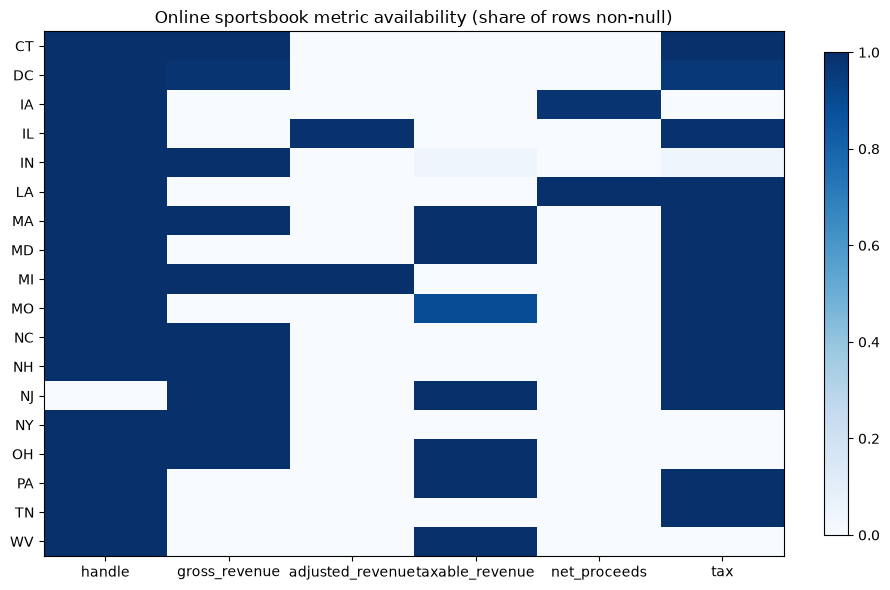

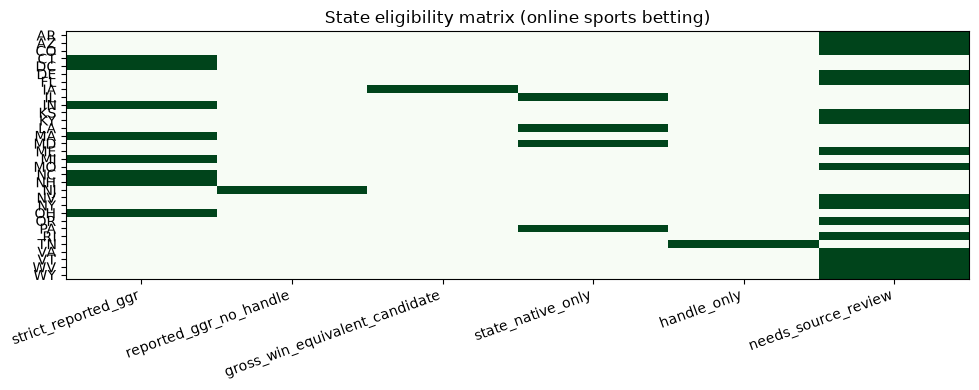

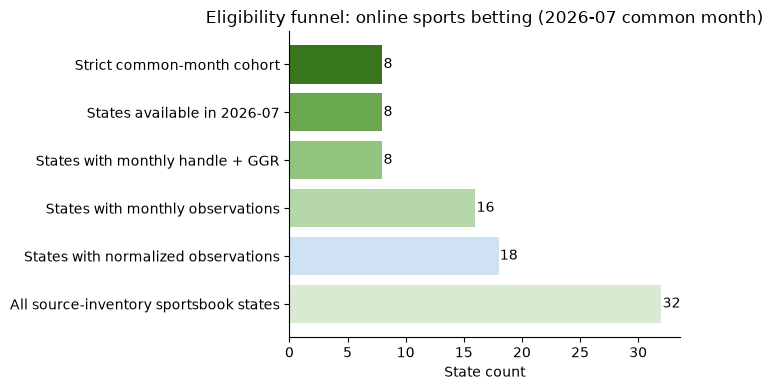

In [10]:
heatmap_cols = [
    "handle_share", "gross_revenue_share", "adjusted_revenue_share",
    "taxable_revenue_share", "net_proceeds_share", "tax_share",
]
heat = inventory.loc[inventory["vertical"] == "online_sports_betting"].copy()
heat = heat.set_index("state_code")[
    ["handle_share", "gross_revenue_share", "adjusted_revenue_share", "taxable_revenue_share", "net_proceeds_share", "tax_share"]
]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heat.fillna(0).values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([c.replace("_share", "") for c in heat.columns], rotation=0)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Online sportsbook metric availability (share of rows non-null)")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
plt.show()

elig = metric_contract.loc[metric_contract["vertical"] == "online_sports_betting"].copy()
class_order = [
    "strict_reported_ggr", "reported_ggr_no_handle", "gross_win_equivalent_candidate",
    "state_native_only", "handle_only", "needs_source_review", "unusable_or_quarantined",
]
elig["comparison_class"] = pd.Categorical(elig["comparison_class"], categories=class_order, ordered=True)
elig_matrix = pd.crosstab(elig["state_code"], elig["comparison_class"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(elig_matrix.values, aspect="auto", cmap="Greens")
ax.set_xticks(range(len(elig_matrix.columns)))
ax.set_xticklabels(elig_matrix.columns, rotation=20, ha="right")
ax.set_yticks(range(len(elig_matrix.index)))
ax.set_yticklabels(elig_matrix.index)
ax.set_title("State eligibility matrix (online sports betting)")
fig.tight_layout()
plt.show()

inventory_sports = sorted(coverage.loc[coverage["vertical"] == "online_sports_betting", "state_code"].unique())
observed_sports = sorted(latest.loc[latest["vertical"] == "online_sports_betting", "state_code"].unique())
monthly_states = sorted(sports_period.loc[sports_period["frequency"] == "monthly", "state_code"].unique())
handle_ggr_states = sorted(
    sports_period.loc[
        (sports_period["frequency"] == "monthly")
        & sports_period["handle"].notna()
        & (sports_period["handle"] > 0)
        & (sports_period["revenue_basis"] == "GGR"),
        "state_code",
    ].unique()
)
common_month_count = len(common_month_cohort)
funnel = pd.Series(
    {
        "All source-inventory sportsbook states": len(inventory_sports),
        "States with normalized observations": len(observed_sports),
        "States with monthly observations": len(monthly_states),
        "States with monthly handle + GGR": len(handle_ggr_states),
        f"States available in {COMMON_MONTH:%Y-%m}": common_month_count,
        "Strict common-month cohort": common_month_count,
    }
)
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d9ead3", "#cfe2f3", "#b6d7a8", "#93c47d", "#6aa84f", "#38761d"]
ax.barh(funnel.index, funnel.values, color=colors[: len(funnel)])
for i, v in enumerate(funnel.values):
    ax.text(v + 0.1, i, str(v), va="center")
ax.set_xlabel("State count")
ax.set_title(f"Eligibility funnel: online sports betting ({COMMON_MONTH:%Y-%m} common month)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()


## 13. State research priorities

**What.** Prioritize collector enrichment, new states, and blocked sources based on this audit.

**Why.** Production work should follow evidence, not ad-hoc expansion.


In [11]:
completed = pd.DataFrame(
    [
        {
            "item": "New Jersey GGR replay",
            "status": "completed",
            "note": "Controlled replay promoted; 1,422 operator GGR rows across 98 months; handle remains unavailable",
        },
        {
            "item": "Massachusetts Accrual Win enrichment",
            "status": "completed",
            "note": "Accrual Win populated in gross_revenue; Taxable Gaming Revenue retained separately; MA is strict-GGR eligible",
        },
    ]
)
print("Completed work")
display(completed)

priorities = pd.DataFrame(
    [
        {"priority": 1, "item": "Metric contract approval", "action": "Human review and approval of effective-dated cross-state metric contract", "type": "governance"},
        {"priority": 2, "item": "Pennsylvania enrichment", "action": "Capture published Revenue separately from stored taxable revenue", "type": "enrich existing collector"},
        {"priority": 3, "item": "Maryland enrichment", "action": "Capture published hold (handle minus prizes) separately from stored taxable win", "type": "enrich existing collector"},
        {"priority": 4, "item": "Iowa validation", "action": "Historical identity validation for Internet Net Receipts vs handle minus payouts", "type": "research/validation"},
        {"priority": 5, "item": "New York monthly series", "action": "Collect official monthly series for monthly comparisons; retain weekly for monitoring/hold", "type": "enrich existing collector"},
        {"priority": 6, "item": "Colorado", "action": "New collector; reports expose GGR and net sports betting proceeds with retail/online splits", "type": "new collector"},
        {"priority": 7, "item": "Kansas, Maine, Vermont", "action": "Implement as explicitly adjusted/net state-native sources; not gross-win equivalent", "type": "new collector"},
        {"priority": 8, "item": "Blocked sources (AZ, KY, WY, etc.)", "action": "Lower priority until source access improves", "type": "blocked/deferred"},
        {"priority": 9, "item": "Remaining public PDF states", "action": "Continue state-by-state collector coverage where official PDFs/CSVs are public", "type": "new collector"},
    ]
)
print("Pending priorities")
display(priorities)


Completed work
Pending priorities


,item,status,note
0,New Jersey GGR replay,completed,"Controlled replay promoted; 1,422 operator GGR rows across 98 months; handle remains unavailable"
1,Massachusetts Accrual Win enrichment,completed,Accrual Win populated in gross_revenue; Taxable Gaming Revenue retained separately; MA is strict-GGR eligible


,priority,item,action,type
0,1,Metric contract approval,Human review and approval of effective-dated cross-state metric contract,governance
1,2,Pennsylvania enrichment,Capture published Revenue separately from stored taxable revenue,enrich existing collector
2,3,Maryland enrichment,Capture published hold (handle minus prizes) separately from stored taxable win,enrich existing collector
3,4,Iowa validation,Historical identity validation for Internet Net Receipts vs handle minus payouts,research/validation
4,5,New York monthly series,Collect official monthly series for monthly comparisons; retain weekly for monitoring/hold,enrich existing collector
5,6,Colorado,New collector; reports expose GGR and net sports betting proceeds with retail/online splits,new collector
6,7,"Kansas, Maine, Vermont",Implement as explicitly adjusted/net state-native sources; not gross-win equivalent,new collector
7,8,"Blocked sources (AZ, KY, WY, etc.)",Lower priority until source access improves,blocked/deferred
8,9,Remaining public PDF states,Continue state-by-state collector coverage where official PDFs/CSVs are public,new collector


## 14. Final validation and proposed architecture

### Key findings
- **MA Accrual Win is populated and strict-GGR eligible.** Accrual Win is stored in `gross_revenue`; Taxable Gaming Revenue remains separately in `taxable_revenue`. Hold is Accrual Win / settled handle.
- **MA taxable revenue remains separate.** It is retained as a secondary state-native field and is not the selected comparable revenue amount.
- **Strict July 2026 common-month cohort contains eight states:** CT, DC, IN, MA, MI, NC, NH, OH.
- **NJ remains GGR-only** (`reported_ggr_no_handle`) because official handle is unavailable; missing handle remains NULL and is never estimated.
- No incompatible revenue bases were merged.
- No production architecture changed in this notebook.
- NY weekly data supports weekly hold only until a monthly series is collected.
- TN: handle-only reporting regime from 2023-07-01; DB rows begin 2023-11-01.

### Proposed minimal production architecture (after human approval)
1. One reviewed effective-dated metric-contract file (YAML/CSV).
2. One small eligibility helper applying semantic rules and common-period selection.
3. State-specific collectors unchanged in scope.
4. Focused tests for contract rows and eligibility edges.
5. Existing SQLite schema unless this review proves a specific column is necessary.

**Do not implement in this notebook.**


In [12]:
DB_HASH_AFTER = sha256_file(DATABASE_PATH)
print("Database hash (after):", DB_HASH_AFTER)
assert DB_HASH_AFTER.lower() == DB_HASH_BEFORE.lower() == EXPECTED_DB_HASH.lower()
connection.close()
print("Notebook completed offline with read-only database access.")


Database hash (after): 62afd2b97459f151e62fbbf24c7e0d0fe5a52e9dee829931d2554b9b1529d388
Notebook completed offline with read-only database access.
